# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

# 1. Coleta dos dados

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';')

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


Legenda dos dados:

*   **CustomerID** : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

*   **Genero** : O genero dos nossos clientes.

*   **Idoso** : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

*   **Casado** : Se nosso cliente é casado ou não.

*   **Dependents** : Se cliente tem dependentes.

*   **Tempo_como_Cliente** : Tempo em meses que nosso cliente está com a nossa empresa.

*   **PhoneService** : Se ele contratou serviço telefônico com a nossa empresa.

*   **Servico_Internet** : Qual o tipo de serviço de internet contratado.

*   **Servico_Seguranca** : Se ele contratou serviço de segurança com a nossa empresa.

*   **Suporte_Tecnico** : Se já acionou o suporte técnico.

*   **StreamingTV** : Se ele contratou serviço de streaming para TV.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **PaymentMethod** : Forma de Pagamento.

*   **Pagamento_Mensal** : Quanto o cliente pagava mensalmente.

*   **Total_Pago** : Total já pago pelo cliente para nossa companhia.

*   **Churn** : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.




# 2. Verificação Inicial

In [3]:
# Verificando a quantidade de linhas e colunas
df.shape

(2500, 16)

In [4]:
# Verificando os tipos de dados
df.dtypes

customerID             object
Genero                 object
Idoso                   int64
Casado                 object
Dependents             object
Tempo_como_Cliente      int64
PhoneService           object
Servico_Internet       object
Servico_Seguranca      object
Suporte_Tecnico        object
StreamingTV            object
Tipo_Contrato          object
PaymentMethod          object
Pagamento_Mensal      float64
Total_Pago            float64
Churn                  object
dtype: object

**Podemos observar que:**

* O dataset possui 2500 dados e 16 variáveis;
* Não vamos considerar a variável 'CustomerID', porque não agrega valor na análise exploratória e aplicação do modelo preditivos, já que serve para identificar um consumidor de forma individual.
* o dataset possui 12 variáveis categóricas e 4 variáveis numéricas.
* A maioria das colunas são do tipo tipo categórica. É importante ressaltar que as variáveis binárias são do tipo categórica. Portanto, estas variáveis deverão passar por um tratamento para serem convertidas em valores numéricos antes de aplicar o modelo de machine learning.

In [5]:
# Excluindo a coluna 'customerID'
df.drop(columns=["customerID"], inplace=True)
df.head()

,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes


In [6]:
# verificando os valores únicos das variáveis categóricas
colunas_categoricas = ["Casado","Dependents","PhoneService","Servico_Internet",
            "Servico_Seguranca","Suporte_Tecnico","StreamingTV",
            "Tipo_Contrato","PaymentMethod","Churn","Genero"]

for c in colunas_categoricas:
    if c in df.columns:
        print("\n", c, ":", df[c].unique())


 Casado : ['Yes' 'No']

 Dependents : ['No' 'Yes']

 PhoneService : ['No' 'Yes' nan]

 Servico_Internet : ['DSL' 'Fiber optic' 'dsl' 'No']

 Servico_Seguranca : ['No' 'Yes' 'No internet service']

 Suporte_Tecnico : ['No' 'Yes' 'No internet service']

 StreamingTV : ['No' 'Yes' 'No internet service']

 Tipo_Contrato : ['Month-to-month' 'One year' 'Two year']

 PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

 Churn : ['No' 'Yes' nan]

 Genero : ['Female' 'Male' nan 'F' 'M' 'f']


# 3. Verificando e tratando valores nulos

In [7]:
# Verificando a quantidade de valores nulos por variável
df.isnull().sum()

Genero                  12
Idoso                    0
Casado                   0
Dependents               0
Tempo_como_Cliente       0
PhoneService          1482
Servico_Internet         0
Servico_Seguranca        0
Suporte_Tecnico          0
StreamingTV              0
Tipo_Contrato            0
PaymentMethod            0
Pagamento_Mensal       325
Total_Pago               0
Churn                    5
dtype: int64

In [8]:
# Convertendo a quantidade de valores nulos em porcentagem
(df.isnull().sum() / len(df)) * 100

Genero                 0.48
Idoso                  0.00
Casado                 0.00
Dependents             0.00
Tempo_como_Cliente     0.00
PhoneService          59.28
Servico_Internet       0.00
Servico_Seguranca      0.00
Suporte_Tecnico        0.00
StreamingTV            0.00
Tipo_Contrato          0.00
PaymentMethod          0.00
Pagamento_Mensal      13.00
Total_Pago             0.00
Churn                  0.20
dtype: float64

### 3.1 Excluindo dados faltantes da variável "Churn"

In [9]:
df.dropna(subset=['Churn'], inplace=True)
df.shape

(2495, 15)

Como a coluna Churn possui apenas 5 valores faltantes em 2.500 linhas, 0,2%, é mais adequado excluir essas linhas do que imputar, pois o impacto na análise é mínimo e evita criar rótulos artificiais.

### 3.2 Substituindo os valores faltantes da coluna "PhoneService"

In [10]:
moda_phone_service = df["PhoneService"].mode(dropna=True)[0]
df["PhoneService"].fillna(moda_phone_service, inplace=True)

print("Moda PhoneService:", moda_phone_service)
df["PhoneService"].isna().sum()

Moda PhoneService: Yes


0

PhoneService é categórica (Yes/No). Usei a moda por representar o valor mais frequente e preservar o padrão dominante sem distorcer a distribuição.

### 3.3 Substituindo os valores faltantes da coluna "Genero"

In [11]:
moda_genero = df["Genero"].mode(dropna=True)[0]
df["Genero"].fillna(moda_genero, inplace=True)

print("Moda Genero:", moda_genero)
df["Genero"].isna().sum()

Moda Genero: Male


0

### 3.4 Substituindo os valores faltantes da coluna "Pagamento_Mensal"

In [12]:
mediana_pagamento_mensal = df["Pagamento_Mensal"].median()
media_pagamento_mensal = df["Pagamento_Mensal"].mean()

print("Média:", media_pagamento_mensal, "| Mediana:", mediana_pagamento_mensal)

df["Pagamento_Mensal"].fillna(mediana_pagamento_mensal, inplace=True)
df["Pagamento_Mensal"].isna().sum()

Média: 65.60756321839081 | Mediana: 71.45


0

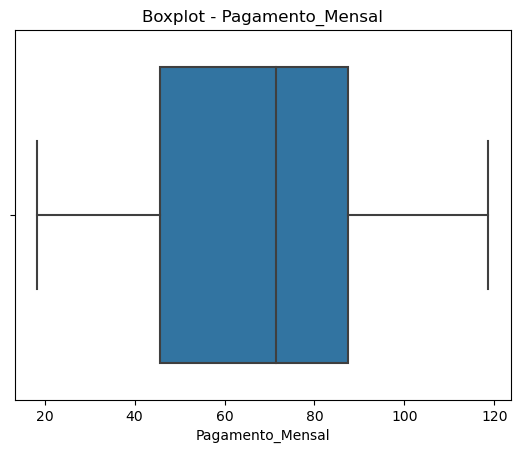

In [13]:
sns.boxplot(x=df["Pagamento_Mensal"])
plt.title("Boxplot - Pagamento_Mensal")
plt.show()

O boxplot não indica outliers extremos (não há pontos fora dos bigodes). Mesmo assim, optei pela mediana por ser uma medida mais robusta e por haver diferença entre média e mediana, sugerindo possível assimetria na distribuição.

# 4. Verificando valores digitados incorretamente (maiúsculas/minúsculas) e corrigindo inconsistências de escrita.

In [14]:
# Padronizando a variável Genero (F/f -> Female; M -> Male)
df["Genero"] = df["Genero"].replace({
    "F": "Female",
    "f": "Female",
    "M": "Male"
})

In [15]:
# Padronizando Servico_Internet (dsl -> DSL)
df["Servico_Internet"] = df["Servico_Internet"].replace({"dsl": "DSL"})

In [16]:
# Conferindo valores únicos das variáveis categóricas após a padronização
cols_cat = ["Casado","Dependents","PhoneService","Servico_Internet",
            "Servico_Seguranca","Suporte_Tecnico","StreamingTV",
            "Tipo_Contrato","PaymentMethod","Churn","Genero"]

for c in cols_cat:
    if c in df.columns:
        print("\n", c, "->", df[c].unique())


 Casado -> ['Yes' 'No']

 Dependents -> ['No' 'Yes']

 PhoneService -> ['No' 'Yes']

 Servico_Internet -> ['DSL' 'Fiber optic' 'No']

 Servico_Seguranca -> ['No' 'Yes' 'No internet service']

 Suporte_Tecnico -> ['No' 'Yes' 'No internet service']

 StreamingTV -> ['No' 'No internet service' 'Yes']

 Tipo_Contrato -> ['Month-to-month' 'One year' 'Two year']

 PaymentMethod -> ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

 Churn -> ['No' 'Yes']

 Genero -> ['Female' 'Male']


# 5. Converter as variáveis categóricas binárias para numéricas

In [17]:
# Convertendo Genero (Female/Male) para 0/1
df["Genero"] = df["Genero"].map({"Female": 0, "Male": 1}).astype("Int64")

In [18]:
# Convertendo variáveis binárias (Yes/No) para 0/1
bin_cols = ["Casado","Dependents","PhoneService", "Churn"]
for c in bin_cols:
    df[c] = df[c].map({"No": 0, "Yes": 1}).astype("Int64")

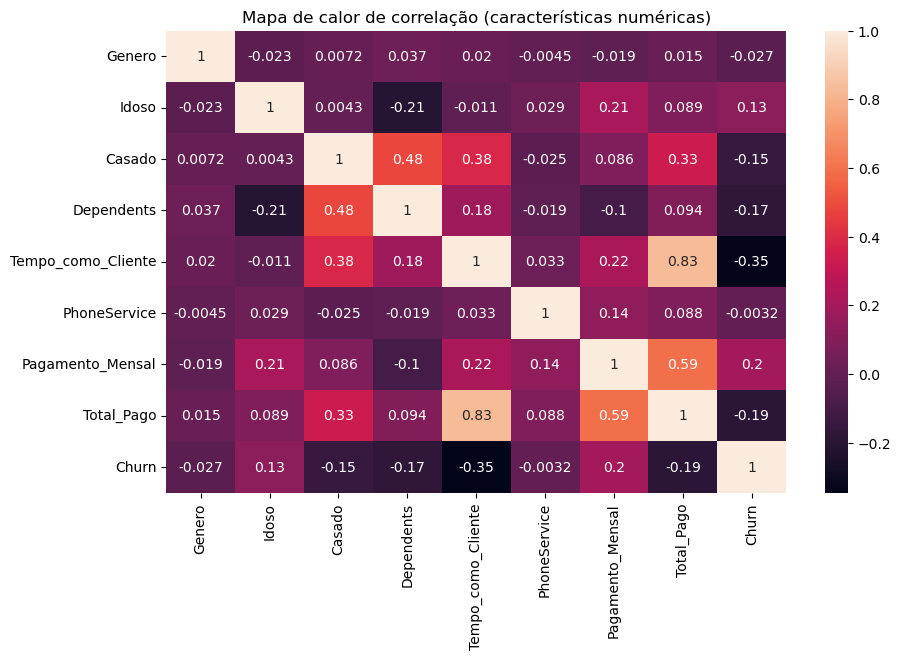

In [19]:
# Matriz de correlação após converter variáveis binárias
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Mapa de calor de correlação (características numéricas)")
plt.show()

Após a conversão das variáveis binárias, o heatmap de correlação mostra que Tempo_como_Cliente tem correlação negativa moderada com Churn com -0,35, sugerindo que clientes mais antigos tendem a cancelar menos. Também observamos correlação alta entre Tempo_como_Cliente e Total_Pago com 0,83, o que é esperado, pois clientes com mais tempo acumulam maior valor pago.


Variáveis com múltiplas categorias (Tipo_Contrato, PaymentMethod, Servico_Internet) serão tratadas com one-hot encoding na etapa de modelagem.

# 5. Padronizando o nomes das colunas

In [20]:
df.rename(columns={
    'Dependents': 'Dependentes',
    'PhoneService': 'Servico_telefone',
    'PaymentMethod': 'Metodo_pagamento'
    
}, inplace=True)
df.head()

,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Servico_telefone,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,Metodo_pagamento,Pagamento_Mensal,Total_Pago,Churn
0,0,0,1,0,1,0,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,DSL,Yes,Yes,No,One year,Bank transfer (automatic),71.45,1840.75,0
4,1,0,0,0,2,1,Fiber optic,No,No,No,Month-to-month,Electronic check,71.45,151.65,1
